<a href="https://colab.research.google.com/github/nibaskumar24n-bot/morph_bio/blob/main/Inside_fold_revised_ElasticNet_stable_gene_Repeatedkfold_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q",
                "xgboost", "shap", "scikit-learn",
                "pandas", "numpy", "matplotlib",
                "seaborn"], check=True)
print("✅ All packages installed!")

✅ All packages installed!


In [2]:
DESCRIP_FILE  = 'matched_ko_full_rows_2.csv'
METADATA_FILE = 'metadata.tsv'

print('✅ Files ready:')
print(f'   descrip  → {DESCRIP_FILE}')
print(f'   metadata → {METADATA_FILE}')

✅ Files ready:
   descrip  → matched_ko_full_rows_2.csv
   metadata → metadata.tsv


In [3]:
TARGET_COLUMN  = "Groups"
CLASS_POSITIVE = "T2DM"
CLASS_NEGATIVE = "Control"

TOP_N        = 10
N_CV_FOLDS   = 5
N_REPEATS    = 10
RANDOM_STATE = 42

print("✅ Configuration set:")
print(f"  Descrip file  : {DESCRIP_FILE}")
print(f"  Metadata file : {METADATA_FILE}")
print(f"  Target column : '{TARGET_COLUMN}'  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Top N genes   : {TOP_N}")
print(f"  CV folds      : {N_CV_FOLDS}")
print(f"  CV repeats    : {N_REPEATS}")
print(f"  Total CV evals: {N_CV_FOLDS * N_REPEATS}")

✅ Configuration set:
  Descrip file  : matched_ko_full_rows_2.csv
  Metadata file : metadata.tsv
  Target column : 'Groups'  (T2DM vs Control)
  Top N genes   : 10
  CV folds      : 5
  CV repeats    : 10
  Total CV evals: 50


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (RepeatedStratifiedKFold,
                                     RandomizedSearchCV)
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import ElasticNetCV
from sklearn.metrics         import (ConfusionMatrixDisplay, classification_report,
                                     roc_auc_score, roc_curve, auc)
from collections import defaultdict, Counter
from scipy import stats
from xgboost import XGBClassifier
import shap

print("✅ Libraries imported!")

✅ Libraries imported!


In [5]:
raw = pd.read_csv(DESCRIP_FILE, index_col=0, comment='#')

desc_col = next((c for c in raw.columns if 'desc' in c.lower()), None)

if desc_col:
    annot_raw  = raw[[desc_col]].copy()
    gene_table = raw.drop(columns=[desc_col])
else:
    annot_raw  = pd.DataFrame(index=raw.index)
    gene_table = raw.copy()

# KO rows, sample columns → transpose
gene_table = gene_table.T
gene_table = gene_table.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Gene table : {gene_table.shape[0]} samples × {gene_table.shape[1]} KO genes")
print(f"  Sample IDs : {gene_table.index[:3].tolist()}")
print(f"  KO IDs     : {gene_table.columns[:3].tolist()}")

Gene table : 116 samples × 1674 KO genes
  Sample IDs : ['SRR36668761', 'SRR36668762', 'SRR36668763']
  KO IDs     : ['K00004', 'K00006', 'K00068']


In [6]:
def split_desc(val):
    val = str(val)
    if ';' in val:
        gene_part, def_part = val.split(';', 1)
        return gene_part.strip().split(',')[0].strip(), def_part.strip()
    return val.strip(), val.strip()

if desc_col:
    annot_raw[['gene_name', 'definition']] = annot_raw[desc_col].apply(
        lambda x: pd.Series(split_desc(x))
    )
    annot_df = annot_raw[['gene_name', 'definition']].copy()
    annot_df.index.name = 'KO'
else:
    annot_df = pd.DataFrame(index=gene_table.columns)
    annot_df['gene_name']  = 'Unknown'
    annot_df['definition'] = 'No annotation'

print(f"✅ {len(annot_df)} KO annotations parsed")
print(annot_df.head(5).to_string())

✅ 1674 KO annotations parsed
         gene_name                                                                                                          definition
KO                                                                                                                                    
K00004         BDH  (R,R)-butanediol dehydrogenase / meso-butanediol dehydrogenase / diacetyl reductase [EC:1.1.1.4 1.1.1.- 1.1.1.303]
K00006        GPD1                                                              glycerol-3-phosphate dehydrogenase (NAD+) [EC:1.1.1.8]
K00068        srlD                                                                 sorbitol-6-phosphate 2-dehydrogenase [EC:1.1.1.140]
K00086        dhaT                                                                        1,3-propanediol dehydrogenase [EC:1.1.1.202]
K00094  E1.1.1.251                                                               galactitol-1-phosphate 5-dehydrogenase [EC:1.1.1.251]


In [7]:
sep = '\t' if METADATA_FILE.endswith('.tsv') else ','
metadata = pd.read_csv(METADATA_FILE, sep=sep, index_col=0)
metadata.index = metadata.index.astype(str)
if str(metadata.index[0]).startswith('#'):
    metadata = metadata.iloc[1:]

gene_table.index = gene_table.index.astype(str)

common = gene_table.index.intersection(metadata.index)
print(f"Samples in gene table : {len(gene_table)}")
print(f"Samples in metadata   : {len(metadata)}")
print(f"Common samples        : {len(common)}")

if len(common) == 0:
    raise ValueError("❌ No common samples! Check sample ID formatting.")

gene_table = gene_table.loc[common]
metadata   = metadata.loc[common].dropna(subset=[TARGET_COLUMN])
gene_table = gene_table.loc[metadata.index]
print(f"Samples after dropping missing target: {len(gene_table)}")

Samples in gene table : 116
Samples in metadata   : 116
Common samples        : 116
Samples after dropping missing target: 116


In [8]:
# Normalise: relative abundance → log(CPM + 1)
gene_table = gene_table.div(gene_table.sum(axis=1), axis=0)
gene_table = np.log1p(gene_table * 1e6)

# Zero-variance filter
gene_table = gene_table.loc[:, gene_table.var() > 0]
print(f"Genes after zero-variance filter: {gene_table.shape[1]}")

X             = gene_table.values
feature_names = gene_table.columns.tolist()
le            = LabelEncoder()
y             = le.fit_transform(metadata[TARGET_COLUMN].astype(str).values)
classes       = le.classes_
n_classes     = len(classes)

print(f"\nFinal feature matrix before Elastic Net : {X.shape}")
print(f"Target classes                          : {list(classes)}")
print(f"Class counts                            : {dict(zip(classes, np.bincount(y)))}")

Genes after zero-variance filter: 1674

Final feature matrix before Elastic Net : (116, 1674)
Target classes                          : ['Control', 'T2DM']
Class counts                            : {'Control': np.int64(38), 'T2DM': np.int64(78)}


In [9]:
param_dist = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [3, 4, 5, 6],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "subsample"       : [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

cv_scores               = []
best_params_per_fold    = []
selected_genes_per_fold = []

X_full             = X.copy()
feature_names_full = feature_names.copy()

cv_outer = RepeatedStratifiedKFold(n_splits=N_CV_FOLDS, n_repeats=N_REPEATS,
                                    random_state=RANDOM_STATE)

print(f"Running nested CV with Elastic Net inside each fold...")
print(f"({N_CV_FOLDS} folds × {N_REPEATS} repeats = {N_CV_FOLDS*N_REPEATS} outer folds)\n")

for fold_i, (train_idx, test_idx) in enumerate(cv_outer.split(X_full, y)):

    X_tr_raw, X_te_raw = X_full[train_idx], X_full[test_idx]
    y_tr, y_te         = y[train_idx], y[test_idx]

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr_raw)
    X_te_scaled = fold_scaler.transform(X_te_raw)

    fold_enet = ElasticNetCV(
        l1_ratio     = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas       = np.logspace(-4, 1, 50),
        cv           = 3,
        max_iter     = 10000,
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    )
    fold_enet.fit(X_tr_scaled, y_tr)

    # ── FIX: keep all nonzero coefficients — principled L1 selection ─
    # ElasticNet's L1 penalty drives irrelevant features to exactly zero.
    # Any nonzero coefficient is already mathematically selected.
    # Using nonzero.mean() as a secondary threshold is arbitrary and
    # unjustified — removed.
    fold_coef           = np.abs(fold_enet.coef_)
    fold_selected_idx   = np.where(fold_coef > 0)[0]
    fold_selected_genes = [feature_names_full[i] for i in fold_selected_idx]
    selected_genes_per_fold.append(fold_selected_genes)

    if len(fold_selected_idx) == 0:
        fold_selected_idx = np.argsort(fold_coef)[-15:]
    # ─────────────────────────────────────────────────────────────────

    X_tr_sel = X_tr_raw[:, fold_selected_idx]
    X_te_sel = X_te_raw[:, fold_selected_idx]

    cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=30,
        scoring="roc_auc",
        cv=cv_inner,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_tr_sel, y_tr)

    fold_proba = search.best_estimator_.predict_proba(X_te_sel)
    fold_auc   = roc_auc_score(y_te, fold_proba[:, 1])
    cv_scores.append(fold_auc)
    best_params_per_fold.append(search.best_params_)

    if (fold_i + 1) % 10 == 0:
        print(f"  Fold {fold_i+1:3d}/{N_CV_FOLDS*N_REPEATS} — "
              f"AUC: {fold_auc:.4f}  |  genes selected: {len(fold_selected_idx)}")

cv_scores = np.array(cv_scores)
print(f"\nNested CV Results ({N_CV_FOLDS}×{N_REPEATS} = {N_CV_FOLDS*N_REPEATS} evaluations):")
print(f"  Mean AUC : {cv_scores.mean():.4f}")
print(f"  Std AUC  : {cv_scores.std():.4f}")
print(f"  Min AUC  : {cv_scores.min():.4f}")
print(f"  Max AUC  : {cv_scores.max():.4f}")

# ── FIX: best_params from median-AUC fold — not majority vote ────────
# Majority vote across 50 folds is a heuristic with no statistical basis.
# The fold closest to the median AUC is a principled representative
# of typical model behaviour across the CV procedure.
median_auc  = np.median(cv_scores)
median_idx  = int(np.argmin(np.abs(cv_scores - median_auc)))
best_params = best_params_per_fold[median_idx]
print(f"\nBest params (median-AUC fold, AUC={cv_scores[median_idx]:.4f}): {best_params}")
# ─────────────────────────────────────────────────────────────────────

# Stable genes
gene_counts  = Counter(g for fold in selected_genes_per_fold for g in fold)
total_folds  = N_CV_FOLDS * N_REPEATS
stable_genes = [g for g, cnt in gene_counts.items() if cnt >= total_folds * 0.5]

print(f"\nStable genes (selected in ≥50% of folds): {len(stable_genes)}")
for g in stable_genes:
    gname = annot_df.loc[g, 'gene_name'] if g in annot_df.index else 'Unknown'
    count = gene_counts[g]
    print(f"  {g:10s}  {gname:25s}  selected in {count}/{total_folds} folds "
          f"({count/total_folds*100:.0f}%)")

selected_idx  = [feature_names_full.index(g) for g in stable_genes]
X             = X_full[:, selected_idx]
feature_names = stable_genes

model = XGBClassifier(
    **best_params,
    eval_metric  = "logloss",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)
model.fit(X, y)
print(f"✅ Final model trained on {len(feature_names)} stable genes")

final_scaler  = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_full)
final_enet    = ElasticNetCV(
    l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas   = np.logspace(-4, 1, 50),
    cv       = 3,
    max_iter = 10000,
    random_state = RANDOM_STATE,
    n_jobs   = -1,
)
final_enet.fit(X_full_scaled, y)
final_coef     = np.abs(final_enet.coef_)
AUTO_THRESHOLD = float(final_coef[final_coef > 0].mean()) if (final_coef > 0).any() else 0.0

print(f"\n✅ Final feature matrix : {X.shape[0]} samples × {X.shape[1]} genes")
print(f"Auto threshold (ref)   : {AUTO_THRESHOLD:.6f}")
print("\n✅ Final model trained on stable genes ✅")

Running nested CV with Elastic Net inside each fold...
(5 folds × 10 repeats = 50 outer folds)

  Fold  10/50 — AUC: 0.9667  |  genes selected: 297
  Fold  20/50 — AUC: 1.0000  |  genes selected: 157
  Fold  30/50 — AUC: 1.0000  |  genes selected: 174
  Fold  40/50 — AUC: 1.0000  |  genes selected: 103
  Fold  50/50 — AUC: 0.9333  |  genes selected: 177

Nested CV Results (5×10 = 50 evaluations):
  Mean AUC : 0.9657
  Std AUC  : 0.0404
  Min AUC  : 0.7946
  Max AUC  : 1.0000

Best params (median-AUC fold, AUC=0.9766): {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Stable genes (selected in ≥50% of folds): 113
  K00068      srlD                       selected in 31/50 folds (62%)
  K00112      glpB                       selected in 39/50 folds (78%)
  K00113      glpC                       selected in 38/50 folds (76%)
  K01026      pct                        selected in 37/50 folds (74%)
  K01046      lip  

In [10]:
importances   = model.feature_importances_
importance_df = pd.DataFrame({
    "KO"        : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

importance_df['gene_name']  = importance_df['KO'].map(annot_df['gene_name']).fillna('Unknown')
importance_df['definition'] = importance_df['KO'].map(annot_df['definition']).fillna('No annotation')
importance_df['Label'] = importance_df.apply(
    lambda r: r['gene_name'] if r['gene_name'] not in ['', 'Unknown'] else r['KO'], axis=1
)

print("✅ Gene importance computed & annotations mapped")
print(f"\nTop 10 genes by XGBoost gain:")
print(importance_df[['KO','gene_name','Importance','definition']].head(10).to_string(index=False))

✅ Gene importance computed & annotations mapped

Top 10 genes by XGBoost gain:
    KO gene_name  Importance                                                                                                     definition
K06348      kapD    0.173319                                                                                     sporulation inhibitor KapD
K09766    K09766    0.080858                                                                                        uncharacterized protein
K13990      FTCD    0.073260                 glutamate formiminotransferase / formiminotetrahydrofolate cyclodeaminase [EC:2.1.2.5 4.3.1.4]
K01496      hisI    0.069079                                                                phosphoribosyl-AMP cyclohydrolase [EC:3.5.4.19]
K07496    K07496    0.066374                                                                                           putative transposase
K02584      nifA    0.064668                                                     

In [11]:
print("Computing SHAP values on full dataset ...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "KO"       : feature_names,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False).reset_index(drop=True)

label_map = importance_df.set_index("KO")["Label"]
shap_df["Label"]      = shap_df["KO"].map(label_map).fillna(shap_df["KO"])
shap_df["gene_name"]  = shap_df["KO"].map(annot_df["gene_name"]).fillna("Unknown")
shap_df["definition"] = shap_df["KO"].map(annot_df["definition"]).fillna("No annotation")

print("✅ SHAP values computed on full dataset!")
print(f"\nTop 10 genes by SHAP:")
print(shap_df[["KO","gene_name","Mean_SHAP","definition"]].head(10).to_string(index=False))

Computing SHAP values on full dataset ...
✅ SHAP values computed on full dataset!

Top 10 genes by SHAP:
    KO gene_name  Mean_SHAP                                                                                                     definition
K03272      gmhC   0.755260 D-beta-D-heptose 7-phosphate kinase / D-beta-D-heptose 1-phosphate adenosyltransferase [EC:2.7.1.167 2.7.7.70]
K02474      wbpO   0.594132                                                        UDP-N-acetyl-D-galactosamine dehydrogenase [EC:1.1.1.-]
K06937    K06937   0.499481                                             7,8-dihydro-6-hydroxymethylpterin dimethyltransferase [EC:2.1.1.-]
K06348      kapD   0.477101                                                                                     sporulation inhibitor KapD
K02584      nifA   0.419387                                                                                Nif-specific regulatory protein
K07009    K07009   0.361616                                  

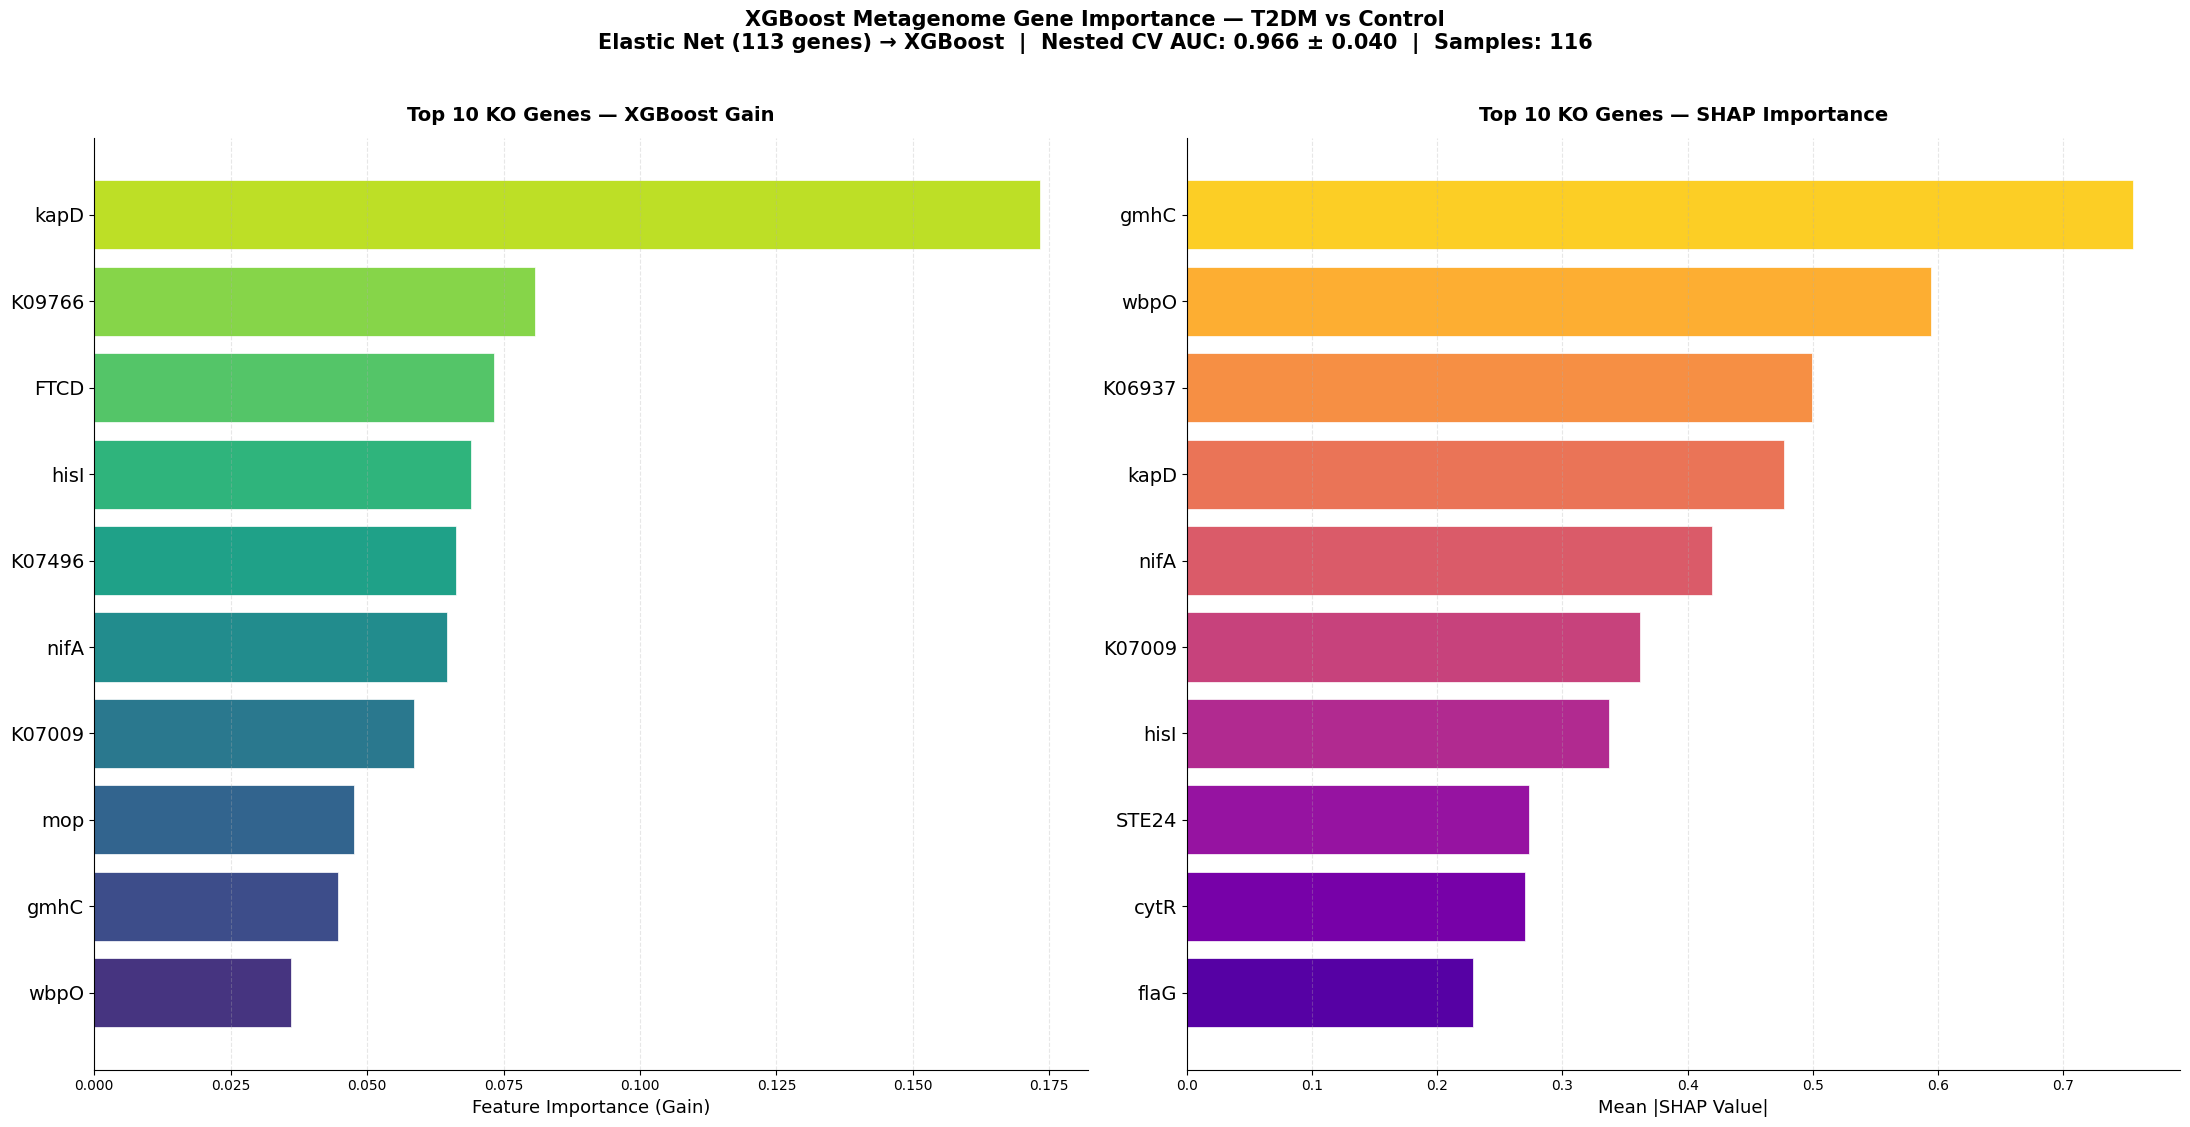

✅ Saved: importance_plots.svg


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

top_imp = importance_df.head(TOP_N).sort_values("Importance")
cmap_a  = plt.cm.viridis(np.linspace(0.15, 0.9, len(top_imp)))
axes[0].barh(top_imp["Label"], top_imp["Importance"],
             color=cmap_a, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Feature Importance (Gain)", fontsize=13)
axes[0].set_title(f"Top {TOP_N} KO Genes — XGBoost Gain",
                  fontsize=14, fontweight="bold", pad=12)
axes[0].tick_params(axis="y", labelsize=14)
axes[0].grid(axis="x", alpha=0.3, linestyle="--")
axes[0].spines[["top","right"]].set_visible(False)

top_shap = shap_df.head(TOP_N).sort_values("Mean_SHAP")
cmap_b   = plt.cm.plasma(np.linspace(0.15, 0.9, len(top_shap)))
axes[1].barh(top_shap["Label"], top_shap["Mean_SHAP"],
             color=cmap_b, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Mean |SHAP Value|", fontsize=13)
axes[1].set_title(f"Top {TOP_N} KO Genes — SHAP Importance",
                  fontsize=14, fontweight="bold", pad=12)
axes[1].tick_params(axis="y", labelsize=14)
axes[1].grid(axis="x", alpha=0.3, linestyle="--")
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle(
    f"XGBoost Metagenome Gene Importance — {CLASS_POSITIVE} vs {CLASS_NEGATIVE}\n"
    f"Elastic Net ({len(feature_names)} genes) → XGBoost  |  "
    f"Nested CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  |  "
    f"Samples: {len(X)}",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("importance_plots.svg", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: importance_plots.svg")

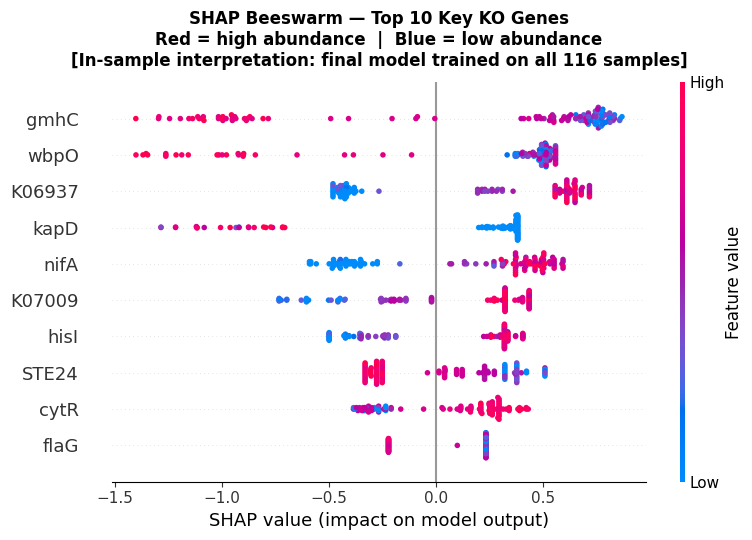

✅ Saved: shap_beeswarm.svg
⚠️  SHAP note: computed in-sample on all 116 samples using the final model.
    Suitable for biological interpretation only — not a performance estimate.


In [13]:
top_fids   = shap_df.head(TOP_N)["KO"].tolist()
top_idx    = [feature_names.index(f) for f in top_fids if f in feature_names]
top_labels = [shap_df.loc[shap_df["KO"] == feature_names[i], "Label"].values[0]
               for i in top_idx]

shap_vals_plot = shap_values[0] if isinstance(shap_values, list) else shap_values
base_val       = (explainer.expected_value[0]
                  if isinstance(explainer.expected_value, (list, np.ndarray))
                  else explainer.expected_value)

explanation = shap.Explanation(
    values        = shap_vals_plot[:, top_idx],
    base_values   = base_val,
    data          = X[:, top_idx],
    feature_names = top_labels
)

plt.figure(figsize=(12, 11))
shap.plots.beeswarm(explanation, show=False, max_display=TOP_N)

# ── FIX: disclose that SHAP is in-sample ─────────────────────────────
plt.title(
    f"SHAP Beeswarm — Top {TOP_N} Key KO Genes\n"
    f"Red = high abundance  |  Blue = low abundance\n"
    f"[In-sample interpretation: final model trained on all {len(y)} samples]",
    fontsize=12, fontweight="bold", pad=12
)
# ─────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig("shap_beeswarm.svg", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_beeswarm.svg")
print("⚠️  SHAP note: computed in-sample on all 116 samples using the final model.")
print("    Suitable for biological interpretation only — not a performance estimate.")

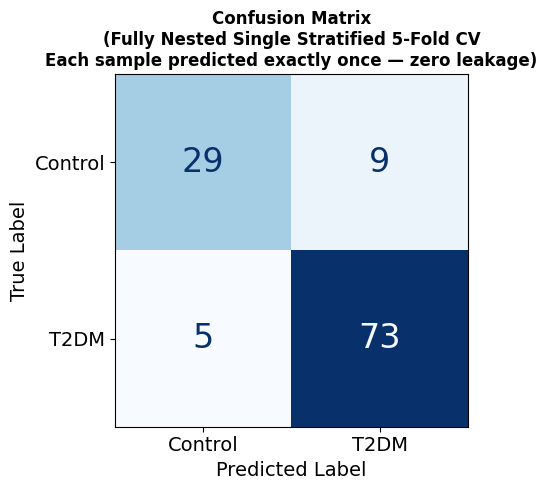


Classification Report (fully nested, each sample predicted exactly once):
              precision    recall  f1-score   support

     Control       0.85      0.76      0.81        38
        T2DM       0.89      0.94      0.91        78

    accuracy                           0.88       116
   macro avg       0.87      0.85      0.86       116
weighted avg       0.88      0.88      0.88       116

✅ Saved: confusion_matrix.svg


In [14]:
# ── Each sample predicted exactly ONCE — no majority-vote smoothing ──
# A single (non-repeated) stratified K-Fold guarantees every sample
# appears in exactly one test fold. ElasticNet is re-run inside each
# fold so there is zero feature-selection leakage.
sample_preds_cm = {}

cv_single = RepeatedStratifiedKFold(n_splits=N_CV_FOLDS, n_repeats=1,
                                     random_state=RANDOM_STATE)

for train_idx, test_idx in cv_single.split(X_full, y):

    X_tr_raw, X_te_raw = X_full[train_idx], X_full[test_idx]
    y_tr               = y[train_idx]

    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr_raw)
    fold_enet   = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 50), cv=3,
        max_iter=10000, random_state=RANDOM_STATE, n_jobs=-1,
    )
    fold_enet.fit(X_tr_scaled, y_tr)

    fold_coef         = np.abs(fold_enet.coef_)
    fold_selected_idx = np.where(fold_coef > 0)[0]
    if len(fold_selected_idx) == 0:
        fold_selected_idx = np.argsort(fold_coef)[-15:]

    X_tr_sel = X_tr_raw[:, fold_selected_idx]
    X_te_sel = X_te_raw[:, fold_selected_idx]

    fold_model = XGBClassifier(
        **best_params, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    fold_model.fit(X_tr_sel, y_tr)
    fold_preds = fold_model.predict(X_te_sel)

    for idx, pred in zip(test_idx, fold_preds):
        sample_preds_cm[idx] = int(pred)

# Sanity checks — both must pass before plotting
assert len(sample_preds_cm) == len(y), \
    f"❌ Expected {len(y)} predictions, got {len(sample_preds_cm)}"
assert sorted(sample_preds_cm.keys()) == list(range(len(y))), \
    "❌ Some sample indices are missing from out-of-fold predictions"

y_pred_cm = np.array([sample_preds_cm[i] for i in range(len(y))])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_cm,
    display_labels=classes, cmap="Blues",
    ax=ax, colorbar=False,
    text_kw={"fontsize": 24}
)
ax.set_title(
    f"Confusion Matrix\n"
    f"(Fully Nested Single Stratified {N_CV_FOLDS}-Fold CV\n"
    f"Each sample predicted exactly once — zero leakage)",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.savefig("confusion_matrix.svg", dpi=300, bbox_inches="tight")
plt.show()

print("\nClassification Report (fully nested, each sample predicted exactly once):")
print(classification_report(y, y_pred_cm, target_names=classes))
print("✅ Saved: confusion_matrix.svg")

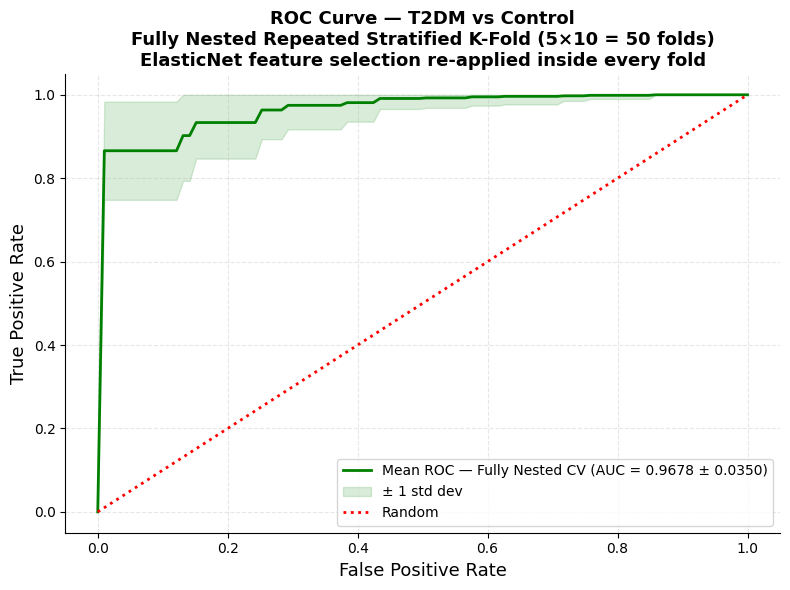

✅ Saved: roc_curve.svg


In [15]:
tprs, aucs_roc = [], []
mean_fpr = np.linspace(0, 1, 100)

rskf = RepeatedStratifiedKFold(n_splits=N_CV_FOLDS, n_repeats=N_REPEATS,
                                random_state=RANDOM_STATE)

for train_idx, test_idx in rskf.split(X_full, y):

    X_tr_raw, X_te_raw = X_full[train_idx], X_full[test_idx]
    y_tr, y_te         = y[train_idx], y[test_idx]

    # ElasticNet re-applied inside every fold — fully nested, zero leakage
    fold_scaler = StandardScaler()
    X_tr_scaled = fold_scaler.fit_transform(X_tr_raw)
    fold_enet   = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 50), cv=3,
        max_iter=10000, random_state=RANDOM_STATE, n_jobs=-1,
    )
    fold_enet.fit(X_tr_scaled, y_tr)

    fold_coef         = np.abs(fold_enet.coef_)
    fold_selected_idx = np.where(fold_coef > 0)[0]
    if len(fold_selected_idx) == 0:
        fold_selected_idx = np.argsort(fold_coef)[-15:]

    X_tr_sel = X_tr_raw[:, fold_selected_idx]
    X_te_sel = X_te_raw[:, fold_selected_idx]

    fold_model = XGBClassifier(
        **best_params, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    fold_model.fit(X_tr_sel, y_tr)
    fold_proba  = fold_model.predict_proba(X_te_sel)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, fold_proba)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    aucs_roc.append(auc(fpr, tpr))

mean_tpr     = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc_roc = np.mean(aucs_roc)
std_auc_roc  = np.std(aucs_roc)
std_tpr      = np.std(tprs, axis=0)
tprs_upper   = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower   = np.maximum(mean_tpr - std_tpr, 0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mean_fpr, mean_tpr, color='green', lw=2,
        label=f'Mean ROC — Fully Nested CV (AUC = {mean_auc_roc:.4f} ± {std_auc_roc:.4f})')
ax.fill_between(mean_fpr, tprs_lower, tprs_upper,
                color='green', alpha=0.15, label='± 1 std dev')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle=':', label='Random')
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title(
    f"ROC Curve — {CLASS_POSITIVE} vs {CLASS_NEGATIVE}\n"
    f"Fully Nested Repeated Stratified K-Fold "
    f"({N_CV_FOLDS}×{N_REPEATS} = {N_CV_FOLDS*N_REPEATS} folds)\n"
    f"ElasticNet feature selection re-applied inside every fold",
    fontsize=13, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("roc_curve.svg", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: roc_curve.svg")

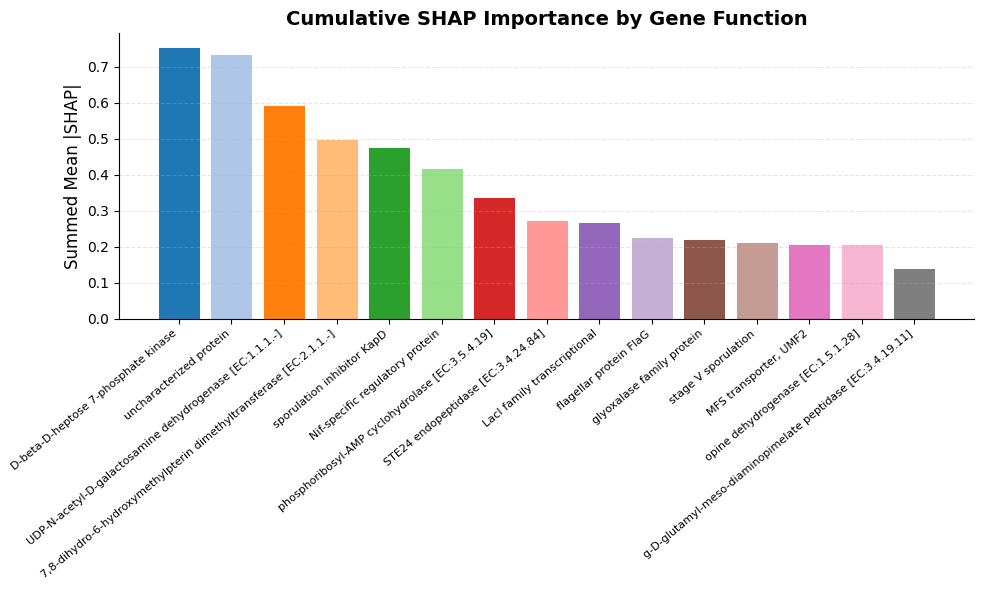

✅ Saved: gene_function_importance.svg


In [16]:
shap_df["Category"] = shap_df["definition"].apply(
    lambda x: " ".join(str(x).split()[:3]) if x not in ["No annotation", "Unknown"] else "Unclassified"
)

cat_imp = (
    shap_df[shap_df["Category"] != "Unclassified"]
    .groupby("Category")["Mean_SHAP"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

if len(cat_imp) > 0:
    palette = sns.color_palette("tab20", len(cat_imp))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(cat_imp)), cat_imp["Mean_SHAP"],
           color=palette, edgecolor="white", linewidth=0.7)
    ax.set_xticks(range(len(cat_imp)))
    ax.set_xticklabels(cat_imp["Category"], rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("Summed Mean |SHAP|", fontsize=12)
    ax.set_title("Cumulative SHAP Importance by Gene Function",
                 fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("gene_function_importance.svg", dpi=300, bbox_inches="tight")
    plt.show()
    print("✅ Saved: gene_function_importance.svg")
else:
    print("⚠️  Function plot skipped — no annotations available.")

In [ ]:
from google.colab import files as colab_files

importance_df.to_csv("xgboost_gene_importance.csv", index=False)
shap_df.to_csv("xgboost_shap_gene_importance.csv", index=False)

print("Creating elasticnet_selected_genes.csv for the stable genes...")
final_scaler_export = StandardScaler()
X_scaled_export     = final_scaler_export.fit_transform(X)
final_enet_export   = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    alphas=np.logspace(-4, 1, 50), cv=5,
    max_iter=10000, random_state=RANDOM_STATE, n_jobs=-1,
)
final_enet_export.fit(X_scaled_export, y)
enet_coef = np.abs(final_enet_export.coef_)

enet_selected_df = pd.DataFrame({
    "KO"        : feature_names,
    "gene_name" : [annot_df.loc[g, 'gene_name'] if g in annot_df.index else 'Unknown'
                   for g in feature_names],
    "enet_coef" : enet_coef,
    "definition": [annot_df.loc[g, 'definition'] if g in annot_df.index else 'No annotation'
                   for g in feature_names],
}).sort_values("enet_coef", ascending=False)
enet_selected_df.to_csv("elasticnet_selected_genes.csv", index=False)
print("✅ CSVs saved")

print("\n" + "═"*70)
print("                 ANALYSIS COMPLETE — SUMMARY")
print("═"*70)
print(f"  Total samples          : {len(X)}")
print(f"  Final signature        : {len(feature_names)} stable genes")
print(f"  Target variable        : {TARGET_COLUMN}  ({CLASS_POSITIVE} vs {CLASS_NEGATIVE})")
print(f"  Best params            : {best_params}")
print(f"  CV strategy            : Nested RepeatedStratifiedKFold ({N_CV_FOLDS}×{N_REPEATS})")
print()
print(f"  ★ PRIMARY metric (unbiased — report this in the paper):")
print(f"    Nested CV AUC        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(f"  ★ SECONDARY metric (fully nested ROC loop — consistent with above):")
print(f"    ROC AUC              : {mean_auc_roc:.4f} ± {std_auc_roc:.4f}")
print()
print(f"  ⚠️  SHAP: computed in-sample (final model on all {len(y)} samples).")
print(f"      Use for biological interpretation only — not performance.")
print()
print(f"  Top 10 Key Genes (SHAP ranking):")
print("  " + "─"*60)
print(shap_df[["KO", "gene_name", "Mean_SHAP", "definition"]].head(10).to_string(index=False))
print("═"*70)

print("\n📥 Downloading result files ...")
files_list = [
    "xgboost_gene_importance.csv",
    "xgboost_shap_gene_importance.csv",
    "elasticnet_selected_genes.csv",
    "importance_plots.svg",
    "shap_beeswarm.svg",
    "confusion_matrix.svg",
    "gene_function_importance.svg",
    "roc_curve.svg",
]
for fname in files_list:
    try:
        colab_files.download(fname)
        print(f"   ✅ {fname}")
    except Exception as e:
        print(f"   ⚠️  {fname} — {e}")

Creating elasticnet_selected_genes.csv for the 29 stable genes...
✅ CSVs saved

══════════════════════════════════════════════════════════════════════
                 ANALYSIS COMPLETE — SUMMARY
══════════════════════════════════════════════════════════════════════
  Total samples          : 116
  Final signature        : 29 stable genes
  Auto threshold (ref)   : 0.010879
  Target variable        : Groups  (T2DM vs Control)
  Best params            : {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 1}
  CV strategy            : Nested RepeatedStratifiedKFold (5×10)
  Nested CV AUC          : 0.9698 ± 0.0340
  ROC AUC (final)        : 0.9905 ± 0.0129

  Top 10 Key Genes (SHAP ranking):
  ────────────────────────────────────────────────────────────
    KO gene_name  Mean_SHAP                                                                                                     definition
K07009    K07009   0.749213 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ xgboost_gene_importance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ gene_function_importance.svg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ roc_curve.svg
